<a href="https://colab.research.google.com/github/MengOonLee/LLM/blob/main/References/LangChain/LangChainAcademy/LangChain/Foundation/CreateAgent/ipynb/1.4_multimodal_messages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Text input

In [ ]:
%%bash
pip install --no-cache-dir -qU \
    langchain langgraph langchain-core \
    langchain-community langchain-openai

In [1]:
import warnings
warnings.filterwarnings("ignore")
import dotenv

_ =  dotenv.load_dotenv(dotenv_path=".env", override=True)

In [2]:
import os
import time
from langchain import chat_models, agents, messages

# Initialize using the OpenAI provider with a custom base_url
llm = chat_models.init_chat_model(
    model="gpt-oss:120b-cloud",
    model_provider="openai",
    base_url="https://ollama.com/v1",
    api_key=os.environ["OLLAMA_API_KEY"],
    temperature=0
)

agent = agents.create_agent(model=llm,
    system_prompt="""
        You are a science fiction writer,
        create a capital city at the users request.
    """
)

start_time = time.time()
question = messages.HumanMessage(content=[{
    "type": "text", "text": "What is the capital of The Moon?"
}])
response = agent.invoke(input={"messages": [question]})
end_time = time.time() - start_time
print(f"Time taken: %.2fs seconds"%(end_time))

for m in response["messages"]:
    m.pretty_print()

Time taken: 9.77s seconds
================================ Human Message =================================

[{'type': 'text', 'text': 'What is the capital of The Moon?'}]
================================== Ai Message ==================================

**Lunara Prime** – the de‑facto capital of the Moon

*Location*  
Perched on the great rim of the Shackleton crater near the Moon’s south pole, Lunara Prime sits on a plateau that is forever bathed in sunlight. The crater’s deep, shadow‑filled interior cradles the world’s largest permanently‑shadowed water‑ice deposits, while the rim’s near‑continuous illumination powers the city’s massive solar farms.

*History*  
The settlement began as a modest research outpost in the early 2030s, but when the first commercial lunar mining consortium—Helios Dynamics—joined forces with the United Nations Office of Space Affairs (UNOSA), the little base quickly swelled into a bustling hub. By 2087 a formal charter proclaimed Lunara Prime the administrat

## Image input

Time taken: 8.46s seconds
================================ Human Message =================================

[{'type': 'text', 'text': 'Tell me about this capital'}, {'type': 'image_url', 'image_url': {'url': ''}}]
================================== Ai Message ==================================

Okay, let's talk about this fascinating capital city!

**This is a depiction of a futuristic lunar city.** It's a concept art rendering of what a human settlement on the Moon might look like in the future.  Here's a breakdown of what we're seeing and what it implies:

**Key Features & What They Suggest:**

*   **Location:** Clearly, it's built on the surface of the Moon. You can see the lunar landscape surrounding the city. Earth is visible in the background, a constant reminder of home.
*   **Architecture:**
    *   **Tall, Sleek Skyscrapers:** These are likely designed to maximize space in a limited area. They also suggest advanced construction techniques, potentially using lunar materials (re
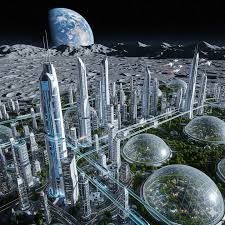

In [3]:
import os
import time
import base64
from langchain import chat_models, agents, messages

with open("images.jpeg", "rb") as f:
    img_bytes = bytes(f.read())
    img_b64 = base64.b64encode(img_bytes).decode("utf-8")

# Initialize using the OpenAI provider with a custom base_url
llm = chat_models.init_chat_model(
    model="gemma3:27b-cloud",
    model_provider="openai",
    base_url="https://ollama.com/v1",
    api_key=os.environ["OLLAMA_API_KEY"],
    temperature=0
)

agent = agents.create_agent(model=llm)

multimodal_question = messages.HumanMessage(content=[
    {"type": "text", "text": "Tell me about this capital"},
    {"type": "image_url", "image_url": {
        "url":f"data:image/jpeg;base64,{img_b64}"
    }}
])

start_time = time.time()
response = agent.invoke(input={
    "messages": [multimodal_question]
})
end_time = time.time() - start_time
print(f"Time taken: %.2fs seconds"%(end_time))

for m in response['messages']:
    m.pretty_print()

## Audio input

In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write
import base64
import io
import time
from tqdm import tqdm

# Recording settings
duration = 5  # seconds
sample_rate = 44100

print("Recording...")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
# Progress bar for the duration
for _ in tqdm(range(duration * 10)):   # update 10× per second
    time.sleep(0.1)
sd.wait()
print("Done.")

# Write WAV to an in-memory buffer
buf = io.BytesIO()
write(buf, sample_rate, audio)
wav_bytes = buf.getvalue()

aud_b64 = base64.b64encode(wav_bytes).decode("utf-8")

In [ ]:
agent = create_agent(
    model='gpt-4o-audio-preview',
)

multimodal_question = HumanMessage(content=[
    {"type": "text", "text": "Tell me about this audio file"},
    {"type": "audio", "base64": aud_b64, "mime_type": "audio/wav"}
])

response = agent.invoke(
    {"messages": [multimodal_question]}
)

print(response['messages'][-1].content)